# Transmission Line Local Relay Modeling

Industry-oriented, single-ended fault classification notebook.

Key constraints:
- Uses the corrected grouped split file only: `../data/processed/stage4_features_grouped_split.csv`.
- Uses only local relay / sending-end features: columns beginning with `send_`.
- Random Forest is the primary model. Other models are benchmarks.
- Validation/test/OOD are separated by `operating_domain_id`.
- Metadata, OOD flags, domain identifiers, scenario IDs, and receiving-end features are excluded from model inputs.


In [1]:
# Imports
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path('../data/processed/stage4_features_grouped_split.csv')
ARTIFACT_DIR = Path('../model_artifacts')
FIGURE_DIR = Path('../figures')
ARTIFACT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)


## 1. Load grouped-split data

This notebook intentionally does **not** load `stage4_features.csv`, because that file contains the older split.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing {DATA_PATH}. Run the grouped-split generation step first.')

df = pd.read_csv(DATA_PATH)
print('Loaded:', DATA_PATH)
print('Shape:', df.shape)
display(df.head())


Loaded: stage4_features_grouped_split.csv
Shape: (11000, 85)


,scenario_id,split,class_name,send_v_rms_a_v,send_v_rms_b_v,send_v_rms_c_v,send_i_rms_a_a,send_i_rms_b_a,send_i_rms_c_a,send_v_rms_ratio_a,...,receive_v_fundamental_residual_ratio_mean,receive_v_crest_factor_mean,receive_v_flatline_fraction_mean,receive_i_spectral_entropy_mean,receive_i_spectral_entropy_max,receive_i_fundamental_residual_ratio_mean,receive_i_crest_factor_mean,receive_i_flatline_fraction_mean,operating_domain_id,is_ood
0,stage4_006324,train,CA,116648.243328,132606.498764,117525.522755,2036.110915,226.360257,2063.679653,0.882780,...,0.055208,1.378418,0.010860,0.114468,0.116752,0.054456,1.608260,0.003342,4,0
1,stage4_000708,train,Healthy,132162.440207,132008.443957,131239.898341,174.127951,173.272842,173.452631,1.000069,...,0.013537,1.426633,0.001671,0.113762,0.116331,0.013120,1.424010,0.000835,8,0
2,stage4_003544,train,CG,131777.450133,132478.795791,77860.328031,235.813976,263.024186,2145.019828,0.999050,...,0.209468,1.618260,0.010025,0.220438,0.428927,0.057327,1.502808,0.001671,4,0
3,stage4_002495,validation,BG,131254.093122,80240.971916,130988.264764,327.626774,3477.002206,300.159245,0.998033,...,0.165770,1.637747,0.013367,0.164593,0.263828,0.044094,1.449196,0.006683,15,0
4,stage4_004132,train,AB,131671.968270,124426.084239,132221.749750,1327.319630,1300.746614,200.872834,0.990787,...,0.026249,1.438159,0.004177,0.114655,0.119182,0.029347,1.424801,0.002506,12,0


## 2. Verify split integrity

The intended grouped split is:
- Train: domains 1-12
- Validation: domains 13-15
- Test: domains 16-18
- OOD test: domains 19-20

In [3]:
required_cols = {'scenario_id', 'split', 'class_name', 'operating_domain_id', 'is_ood'}
missing_cols = sorted(required_cols - set(df.columns))
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

expected_domains = {
    'train': set(range(1, 13)),
    'validation': set(range(13, 16)),
    'test': set(range(16, 19)),
    'ood_test': set(range(19, 21)),
}

print('Split counts:')
display(df['split'].value_counts())

print('Class balance by split:')
display(pd.crosstab(df['split'], df['class_name']))

print('Operating domain by split:')
domain_table = pd.crosstab(df['split'], df['operating_domain_id'])
display(domain_table)

for split_name, expected in expected_domains.items():
    observed = set(df.loc[df['split'].eq(split_name), 'operating_domain_id'].dropna().astype(int).unique())
    if observed != expected:
        raise ValueError(f'{split_name} domains mismatch. observed={sorted(observed)}, expected={sorted(expected)}')

print('Split integrity check passed.')


Split counts:


split
train         6600
validation    1650
test          1650
ood_test      1100
Name: count, dtype: int64

Class balance by split:


class_name,AB,ABC,ABG,AG,BC,BCG,BG,CA,CAG,CG,Healthy
split,,,,,,,,,,,
ood_test,100,100,100,100,100,100,100,100,100,100,100
test,150,150,150,150,150,150,150,150,150,150,150
train,600,600,600,600,600,600,600,600,600,600,600
validation,150,150,150,150,150,150,150,150,150,150,150


Operating domain by split:


operating_domain_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
split,,,,,,,,,,,,,,,,,,,,
ood_test,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,550,550
test,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,550,550,550,0,0
train,550,550,550,550,550,550,550,550,550,550,550,550,0,0,0,0,0,0,0,0
validation,0,0,0,0,0,0,0,0,0,0,0,0,550,550,550,0,0,0,0,0


Split integrity check passed.


## 3. Select local relay / send-end features only

The microcontroller relay sees one end of the line, so all `receive_` columns are excluded.

In [3]:
target_col = 'class_name'
metadata_cols = ['scenario_id', 'split', 'class_name', 'operating_domain_id', 'is_ood']
feature_cols = [c for c in df.columns if c.startswith('send_')]

if not feature_cols:
    raise ValueError('No send_ features found.')

blocked_terms = ['receive_', 'scenario_id', 'split', 'class_name', 'operating_domain_id', 'is_ood', 'fault_type_code', 'fault_enabled']
leaky = [c for c in feature_cols if any(term in c for term in blocked_terms)]
if leaky:
    raise ValueError(f'Potential leakage features selected: {leaky}')

print(f'Selected {len(feature_cols)} local/send-end features:')
for col in feature_cols:
    print(' -', col)


Selected 40 local/send-end features:
 - send_v_rms_a_v
 - send_v_rms_b_v
 - send_v_rms_c_v
 - send_i_rms_a_a
 - send_i_rms_b_a
 - send_i_rms_c_a
 - send_v_rms_ratio_a
 - send_v_rms_ratio_b
 - send_v_rms_ratio_c
 - send_i_rms_ratio_a
 - send_i_rms_ratio_b
 - send_i_rms_ratio_c
 - send_v0_rms_v
 - send_v1_rms_v
 - send_v2_rms_v
 - send_i0_rms_a
 - send_i1_rms_a
 - send_i2_rms_a
 - send_v0_v1_ratio
 - send_v2_v1_ratio
 - send_i0_i1_ratio
 - send_i2_i1_ratio
 - send_active_power_w
 - send_reactive_power_var
 - send_power_factor
 - send_z_magnitude_a_ohm
 - send_z_magnitude_b_ohm
 - send_z_magnitude_c_ohm
 - send_v_rms_imbalance_pct
 - send_i_rms_imbalance_pct
 - send_v_spectral_entropy_mean
 - send_v_spectral_entropy_max
 - send_v_fundamental_residual_ratio_mean
 - send_v_crest_factor_mean
 - send_v_flatline_fraction_mean
 - send_i_spectral_entropy_mean
 - send_i_spectral_entropy_max
 - send_i_fundamental_residual_ratio_mean
 - send_i_crest_factor_mean
 - send_i_flatline_fraction_mean


In [4]:
train_df = df[df['split'].eq('train')].copy()
val_df = df[df['split'].eq('validation')].copy()
test_df = df[df['split'].eq('test')].copy()
ood_df = df[df['split'].eq('ood_test')].copy()

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val, y_val = val_df[feature_cols], val_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]
X_ood, y_ood = ood_df[feature_cols], ood_df[target_col]

splits = {
    'train': (X_train, y_train),
    'validation': (X_val, y_val),
    'test': (X_test, y_test),
    'ood_test': (X_ood, y_ood),
}

print('Prepared split matrices:')
for name, (X_part, y_part) in splits.items():
    print(f'{name:12s} X={X_part.shape}, y={y_part.shape}')


Prepared split matrices:
train        X=(6600, 40), y=(6600,)
validation   X=(1650, 40), y=(1650,)
test         X=(1650, 40), y=(1650,)
ood_test     X=(1100, 40), y=(1100,)


## 4. Evaluation utilities

In [5]:
labels = sorted(df[target_col].unique())

def evaluate_model(model, model_name, splits_to_eval=None, show_reports=True):
    if splits_to_eval is None:
        splits_to_eval = {'validation': (X_val, y_val), 'test': (X_test, y_test), 'ood_test': (X_ood, y_ood)}
    rows = []
    reports = {}
    matrices = {}
    for split_name, (X_part, y_part) in splits_to_eval.items():
        y_pred = model.predict(X_part)
        acc = accuracy_score(y_part, y_pred)
        bal_acc = balanced_accuracy_score(y_part, y_pred)
        rows.append({'model': model_name, 'split': split_name, 'accuracy': acc, 'balanced_accuracy': bal_acc})
        reports[split_name] = classification_report(y_part, y_pred, labels=labels, zero_division=0)
        matrices[split_name] = confusion_matrix(y_part, y_pred, labels=labels)
        if show_reports:
            print(f'\n=== {model_name} | {split_name} ===')
            print(f'Accuracy: {acc:.4f} | Balanced accuracy: {bal_acc:.4f}')
            print(reports[split_name])
    return pd.DataFrame(rows), reports, matrices

def fault_binary_metrics(model, split_name, X_part, y_part):
    y_pred = pd.Series(model.predict(X_part), index=y_part.index)
    actual_fault = ~y_part.eq('Healthy')
    pred_fault = ~y_pred.eq('Healthy')
    false_trip_rate = ((~actual_fault) & pred_fault).sum() / max((~actual_fault).sum(), 1)
    missed_fault_rate = (actual_fault & (~pred_fault)).sum() / max(actual_fault.sum(), 1)
    return {
        'split': split_name,
        'healthy_false_trip_rate': false_trip_rate,
        'fault_missed_detection_rate': missed_fault_rate,
    }


## 5. Sanity checks

The shuffled-label RF should perform near random chance. With 11 classes, random accuracy is about 9%.

In [6]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_summary, _, _ = evaluate_model(dummy, 'Dummy most-frequent', show_reports=False)
display(dummy_summary)

rng = np.random.default_rng(RANDOM_STATE)
y_train_shuffled = pd.Series(rng.permutation(y_train.values), index=y_train.index, name=y_train.name)
shuffle_rf = RandomForestClassifier(
    n_estimators=100, max_depth=8, min_samples_leaf=5, max_features='sqrt',
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
shuffle_rf.fit(X_train, y_train_shuffled)
shuffle_summary, _, _ = evaluate_model(shuffle_rf, 'RF shuffled-label sanity', show_reports=False)
display(shuffle_summary)

max_shuffle_acc = shuffle_summary['accuracy'].max()
if max_shuffle_acc > 0.20:
    raise RuntimeError(f'Shuffled-label accuracy is suspiciously high: {max_shuffle_acc:.3f}')
print('Shuffled-label sanity check passed.')


,model,split,accuracy,balanced_accuracy
0,Dummy most-frequent,validation,0.090909,0.090909
1,Dummy most-frequent,test,0.090909,0.090909
2,Dummy most-frequent,ood_test,0.090909,0.090909


,model,split,accuracy,balanced_accuracy
0,RF shuffled-label sanity,validation,0.080000,0.080000
1,RF shuffled-label sanity,test,0.095758,0.095758
2,RF shuffled-label sanity,ood_test,0.115455,0.115455


Shuffled-label sanity check passed.


## 6. Primary model: conservative Random Forest

In [9]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_baseline.fit(X_train, y_train)
rf_baseline_summary, rf_baseline_reports, rf_baseline_matrices = evaluate_model(rf_baseline, 'Random Forest baseline')
display(rf_baseline_summary)

rf_baseline_binary_rows = [fault_binary_metrics(rf_baseline, name, Xp, yp) for name, (Xp, yp) in splits.items() if name != 'train']
rf_baseline_binary_summary = pd.DataFrame(rf_baseline_binary_rows)
display(rf_baseline_binary_summary)



=== Random Forest baseline | validation ===
Accuracy: 1.0000 | Balanced accuracy: 1.0000
              precision    recall  f1-score   support

          AB       1.00      1.00      1.00       150
         ABC       1.00      1.00      1.00       150
         ABG       1.00      1.00      1.00       150
          AG       1.00      1.00      1.00       150
          BC       1.00      1.00      1.00       150
         BCG       1.00      1.00      1.00       150
          BG       1.00      1.00      1.00       150
          CA       1.00      1.00      1.00       150
         CAG       1.00      1.00      1.00       150
          CG       1.00      1.00      1.00       150
     Healthy       1.00      1.00      1.00       150

    accuracy                           1.00      1650
   macro avg       1.00      1.00      1.00      1650
weighted avg       1.00      1.00      1.00      1650


=== Random Forest baseline | test ===
Accuracy: 1.0000 | Balanced accuracy: 1.0000
             

,model,split,accuracy,balanced_accuracy
0,Random Forest baseline,validation,1.000000,1.000000
1,Random Forest baseline,test,1.000000,1.000000
2,Random Forest baseline,ood_test,0.796364,0.796364


,split,healthy_false_trip_rate,fault_missed_detection_rate
0,validation,0.0,0.000
1,test,0.0,0.000
2,ood_test,0.0,0.049


## 7. Random Forest tuning with GroupKFold

Hyperparameter search is grouped by `operating_domain_id`, preventing random row-level CV leakage across domains.

In [11]:
rf_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [6, 8, 10, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5],
}

group_cv = GroupKFold(n_splits=5)
groups = train_df['operating_domain_id']

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='balanced_accuracy',
    cv=group_cv,
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, y_train, groups=groups)
print('Best RF parameters:', rf_grid.best_params_)
print('Best grouped-CV balanced accuracy:', rf_grid.best_score_)
best_rf = rf_grid.best_estimator_
best_rf_summary, best_rf_reports, best_rf_matrices = evaluate_model(best_rf, 'Random Forest tuned')
display(best_rf_summary)

best_rf_binary_rows = [fault_binary_metrics(best_rf, name, Xp, yp) for name, (Xp, yp) in splits.items() if name != 'train']
best_rf_binary_summary = pd.DataFrame(best_rf_binary_rows)
display(best_rf_binary_summary)


Fitting 5 folds for each of 144 candidates, totalling 720 fits


/home/user1/codingProjects/Fault_Detection_Fall2026/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/user1/codingProjects/Fault_Detection_Fall2026/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/user1/codingProjects/Fault_Detection_Fall2026/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j

Best RF parameters: {'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 200}
Best grouped-CV balanced accuracy: 0.9997575757575758

=== Random Forest tuned | validation ===
Accuracy: 1.0000 | Balanced accuracy: 1.0000
              precision    recall  f1-score   support

          AB       1.00      1.00      1.00       150
         ABC       1.00      1.00      1.00       150
         ABG       1.00      1.00      1.00       150
          AG       1.00      1.00      1.00       150
          BC       1.00      1.00      1.00       150
         BCG       1.00      1.00      1.00       150
          BG       1.00      1.00      1.00       150
          CA       1.00      1.00      1.00       150
         CAG       1.00      1.00      1.00       150
          CG       1.00      1.00      1.00       150
     Healthy       1.00      1.00      1.00       150

    accuracy                           1.00      1650
   macro avg       1.00      1.00      1.00      1

,model,split,accuracy,balanced_accuracy
0,Random Forest tuned,validation,1.000000,1.000000
1,Random Forest tuned,test,1.000000,1.000000
2,Random Forest tuned,ood_test,0.834545,0.834545


,split,healthy_false_trip_rate,fault_missed_detection_rate
0,validation,0.0,0.000
1,test,0.0,0.000
2,ood_test,0.0,0.012


## 8. Benchmark models

These are not the primary deployment choice; they benchmark whether RF is competitive under the same send-only, grouped-split constraints.

In [12]:
benchmark_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'MLP shallow': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(64, 32), activation='relu', alpha=1e-4,
            learning_rate_init=1e-3, early_stopping=True, validation_fraction=0.15,
            max_iter=500, random_state=RANDOM_STATE
        )),
    ]),
}

all_summaries = [rf_baseline_summary.assign(model='Random Forest baseline'), best_rf_summary.assign(model='Random Forest tuned')]
trained_benchmarks = {}

for model_name, model in benchmark_models.items():
    print(f'\nTraining {model_name}...')
    model.fit(X_train, y_train)
    trained_benchmarks[model_name] = model
    summary, _, _ = evaluate_model(model, model_name, show_reports=False)
    all_summaries.append(summary)

comparison = pd.concat(all_summaries, ignore_index=True)
display(comparison.pivot_table(index='model', columns='split', values=['accuracy', 'balanced_accuracy']))



Training Logistic Regression...

Training Gradient Boosting...

Training MLP shallow...


accuracy                      balanced_accuracy  \
split                   ood_test      test validation          ood_test   
model                                                                     
Gradient Boosting       0.440909  0.998788   0.994545          0.440909   
Logistic Regression     0.910000  0.998182   0.994545          0.910000   
MLP shallow             0.943636  0.998182   0.998182          0.943636   
Random Forest baseline  0.796364  1.000000   1.000000          0.796364   
Random Forest tuned     0.834545  1.000000   1.000000          0.834545   

                                             
split                       test validation  
model                                        
Gradient Boosting       0.998788   0.994545  
Logistic Regression     0.998182   0.994545  
MLP shallow             0.998182   0.998182  
Random Forest baseline  1.000000   1.000000  
Random Forest tuned     1.000000   1.000000

## 9. Feature importance and deployability checks

,gini_importance
send_v0_rms_v,0.068268
send_i_rms_ratio_b,0.065183
send_i_rms_ratio_c,0.062710
send_i0_i1_ratio,0.061855
send_i_rms_imbalance_pct,0.060460
send_v0_v1_ratio,0.059479
send_i_rms_ratio_a,0.051964
send_i2_i1_ratio,0.048248
send_z_magnitude_b_ohm,0.045043
send_z_magnitude_c_ohm,0.044738


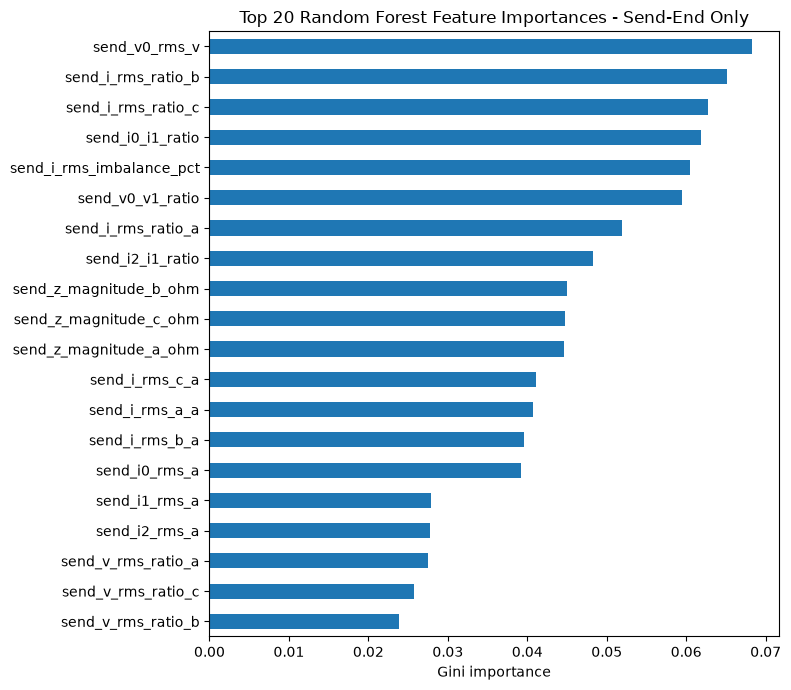

{
  "n_features": 40,
  "n_estimators": 200,
  "max_depth_setting": 8,
  "min_samples_leaf": 1,
  "max_features": "log2"
}


In [11]:
importance = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(importance.to_frame('gini_importance').head(20))

plt.figure(figsize=(8, 7))
importance.head(20).sort_values().plot(kind='barh')
plt.title('Top 20 Random Forest Feature Importances - Send-End Only')
plt.xlabel('Gini importance')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rf_send_only_feature_importance.png', dpi=200)
plt.show()

deployability = {
    'n_features': len(feature_cols),
    'n_estimators': best_rf.n_estimators,
    'max_depth_setting': best_rf.max_depth,
    'min_samples_leaf': best_rf.min_samples_leaf,
    'max_features': best_rf.max_features,
}
print(json.dumps(deployability, indent=2))


## 10. Relay warning/trip state-machine example

The classifier remains stateless. Relay behavior is made stateful by decision logic over consecutive windows.

In [ ]:
def relay_state_machine(probabilities, classes, warning_threshold=0.70, trip_threshold=0.95, consecutive_windows=3):
    classes = list(classes)
    if 'Healthy' not in classes:
        raise ValueError('Classes must include Healthy.')
    healthy_idx = classes.index('Healthy')
    states = []
    abnormal_count = 0
    for row in probabilities:
        p_fault = 1.0 - row[healthy_idx]
        if p_fault >= trip_threshold:
            state = 'Trip'
            abnormal_count += 1
        elif p_fault >= warning_threshold:
            abnormal_count += 1
            state = 'Warning' if abnormal_count >= consecutive_windows else 'Monitor'
        else:
            abnormal_count = 0
            state = 'Normal'
        states.append({'p_fault': p_fault, 'abnormal_count': abnormal_count, 'relay_state': state})
    return pd.DataFrame(states)

# Demonstration on the first 20 OOD rows in file order. For real validation, run this on true consecutive event windows.
ood_probs = best_rf.predict_proba(X_ood.iloc[:20])
relay_demo = relay_state_machine(ood_probs, best_rf.classes_)
display(pd.concat([ood_df[['scenario_id', 'class_name']].iloc[:20].reset_index(drop=True), relay_demo], axis=1))


## 11. Stress-aware split experiment

The original grouped split keeps both harsh domains, 19 and 20, entirely outside training. That is useful for pure OOD testing, but it may be unrealistic for an industry model if deployment includes harsh sensor conditions.

This experiment trains on one harsh domain and holds out the other harsh domain as final OOD:
- Train: domains 1-14 plus 19
- Validation: domain 15
- Test: domains 16-18
- Final OOD: domain 20

In [ ]:
def build_domain_split(data, train_domains, val_domains, test_domains, ood_domains, features):
    split_def = {
        'train': sorted(train_domains),
        'validation': sorted(val_domains),
        'test': sorted(test_domains),
        'ood_test': sorted(ood_domains),
    }
    out = {}
    for split_name, domains in split_def.items():
        part = data[data['operating_domain_id'].isin(domains)].copy()
        out[split_name] = (part[features], part[target_col], part)
    return split_def, out

stress_split_def, stress_splits = build_domain_split(
    df,
    train_domains=list(range(1, 15)) + [19],
    val_domains=[15],
    test_domains=[16, 17, 18],
    ood_domains=[20],
    features=feature_cols,
)

print('Stress-aware split definition:')
print(json.dumps(stress_split_def, indent=2))

for name, (_, y_part, part) in stress_splits.items():
    print(f'{name:12s} rows={len(part):5d} domains={sorted(part.operating_domain_id.unique())}')
    print(y_part.value_counts().sort_index().to_dict())


In [ ]:
X_train_stress, y_train_stress, train_stress_df = stress_splits['train']
X_val_stress, y_val_stress, val_stress_df = stress_splits['validation']
X_test_stress, y_test_stress, test_stress_df = stress_splits['test']
X_ood_stress, y_ood_stress, ood_stress_df = stress_splits['ood_test']

stress_eval_splits = {
    'validation': (X_val_stress, y_val_stress),
    'test': (X_test_stress, y_test_stress),
    'ood_test': (X_ood_stress, y_ood_stress),
}

stress_rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=5, max_features='sqrt',
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
stress_rf.fit(X_train_stress, y_train_stress)
stress_rf_summary, stress_rf_reports, stress_rf_matrices = evaluate_model(
    stress_rf, 'RF stress-aware split', splits_to_eval=stress_eval_splits
)
display(stress_rf_summary)

stress_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
])
stress_lr.fit(X_train_stress, y_train_stress)
stress_lr_summary, _, _ = evaluate_model(
    stress_lr, 'LR stress-aware split', splits_to_eval=stress_eval_splits, show_reports=False
)
display(stress_lr_summary)


## 12. Leave-one-domain-out diagnostic

This identifies which operating domains are intrinsically hard. Each domain is held out once while all other domains are used for training.

In [ ]:
lodo_rows = []
for heldout_domain in sorted(df['operating_domain_id'].unique()):
    train_part = df[~df['operating_domain_id'].eq(heldout_domain)]
    eval_part = df[df['operating_domain_id'].eq(heldout_domain)]
    model = RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=5, max_features='sqrt',
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(train_part[feature_cols], train_part[target_col])
    pred = model.predict(eval_part[feature_cols])
    lodo_rows.append({
        'heldout_domain': int(heldout_domain),
        'rows': len(eval_part),
        'accuracy': accuracy_score(eval_part[target_col], pred),
        'balanced_accuracy': balanced_accuracy_score(eval_part[target_col], pred),
        'is_original_ood_domain': bool(heldout_domain in [19, 20]),
    })

lodo_summary = pd.DataFrame(lodo_rows)
display(lodo_summary)

plt.figure(figsize=(9, 4))
plt.bar(lodo_summary['heldout_domain'], lodo_summary['balanced_accuracy'])
plt.axhline(lodo_summary['balanced_accuracy'].mean(), color='black', linestyle='--', label='mean')
plt.xlabel('Held-out operating domain')
plt.ylabel('Balanced accuracy')
plt.title('Leave-One-Domain-Out RF Diagnostic')
plt.xticks(lodo_summary['heldout_domain'])
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rf_leave_one_domain_out.png', dpi=200)
plt.show()


## 13. Binary fault-detection RF

Industry protection first requires reliable fault detection: `Healthy` vs `Fault`. Fault-type classification is secondary.

In [ ]:
def binary_target(y):
    return np.where(pd.Series(y).eq('Healthy'), 'Healthy', 'Fault')

binary_rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=10, max_features='sqrt',
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
binary_rf.fit(X_train, binary_target(y_train))

binary_rows = []
for split_name, (X_part, y_part) in {'validation': (X_val, y_val), 'test': (X_test, y_test), 'ood_test': (X_ood, y_ood)}.items():
    y_true_bin = binary_target(y_part)
    y_pred_bin = binary_rf.predict(X_part)
    binary_rows.append({
        'model': 'Binary RF original grouped split',
        'split': split_name,
        'accuracy': accuracy_score(y_true_bin, y_pred_bin),
        'balanced_accuracy': balanced_accuracy_score(y_true_bin, y_pred_bin),
    })
    print(f'\nBinary RF | {split_name}')
    print(classification_report(y_true_bin, y_pred_bin, zero_division=0))

binary_rf_summary = pd.DataFrame(binary_rows)
display(binary_rf_summary)


## 14. Hierarchical RF: detect fault, classify family, classify phases

The flat 11-class RF mainly confuses LL with LLG under harsh OOD conditions. A hierarchical structure tests whether separating detection, grounding/family, and phase selection is more stable.

In [ ]:
manifest_path = Path('stage4_bulk_manifest.csv')
if not manifest_path.exists():
    raise FileNotFoundError('stage4_bulk_manifest.csv is required for hierarchical labels.')

manifest_meta = pd.read_csv(manifest_path)[['scenario_id', 'class_name', 'fault_family', 'faulted_phases']]
hier_df = df.merge(manifest_meta, on=['scenario_id', 'class_name'], how='left')
if hier_df[['fault_family', 'faulted_phases']].isna().any().any():
    # Healthy rows have blank faulted_phases in CSV; normalize those after checking family.
    missing_nonhealthy = hier_df[~hier_df['class_name'].eq('Healthy') & hier_df[['fault_family', 'faulted_phases']].isna().any(axis=1)]
    if len(missing_nonhealthy):
        raise ValueError(f'Missing hierarchical metadata for {len(missing_nonhealthy)} non-healthy rows.')

hier_df['fault_family_norm'] = hier_df['fault_family'].fillna('none')
hier_df['faulted_phases_norm'] = hier_df['faulted_phases'].fillna('none').replace('', 'none')

def class_from_family_phase(family, phases):
    if family == 'none' or phases == 'none':
        return 'Healthy'
    if family == 'LG':
        return f'{phases}G'
    if family == 'LL':
        return phases
    if family == 'LLG':
        return f'{phases}G'
    if family == 'LLL':
        return 'ABC'
    return 'Unknown'

def fit_hierarchical_rf(train_part):
    params = dict(n_estimators=300, max_depth=8, min_samples_leaf=5, max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    detect_model = RandomForestClassifier(**params)
    family_model = RandomForestClassifier(**params)
    phase_model = RandomForestClassifier(**params)
    detect_model.fit(train_part[feature_cols], binary_target(train_part[target_col]))
    fault_train = train_part[~train_part[target_col].eq('Healthy')]
    family_model.fit(fault_train[feature_cols], fault_train['fault_family_norm'])
    phase_model.fit(fault_train[feature_cols], fault_train['faulted_phases_norm'])
    return detect_model, family_model, phase_model

def predict_hierarchical(models, eval_part):
    detect_model, family_model, phase_model = models
    detection = detect_model.predict(eval_part[feature_cols])
    preds = []
    fault_mask = detection == 'Fault'
    fam_pred = np.array(['none'] * len(eval_part), dtype=object)
    phase_pred = np.array(['none'] * len(eval_part), dtype=object)
    if fault_mask.any():
        fam_pred[fault_mask] = family_model.predict(eval_part.loc[fault_mask, feature_cols])
        phase_pred[fault_mask] = phase_model.predict(eval_part.loc[fault_mask, feature_cols])
    for fam, ph in zip(fam_pred, phase_pred):
        preds.append(class_from_family_phase(fam, ph))
    return np.array(preds)

hier_train = hier_df[hier_df['split'].eq('train')].copy()
hier_models = fit_hierarchical_rf(hier_train)

hier_rows = []
for split_name in ['validation', 'test', 'ood_test']:
    part = hier_df[hier_df['split'].eq(split_name)].copy()
    pred = predict_hierarchical(hier_models, part)
    hier_rows.append({
        'model': 'Hierarchical RF original grouped split',
        'split': split_name,
        'accuracy': accuracy_score(part[target_col], pred),
        'balanced_accuracy': balanced_accuracy_score(part[target_col], pred),
    })
    print(f'\nHierarchical RF | {split_name}')
    print(classification_report(part[target_col], pred, labels=labels, zero_division=0))

hier_summary = pd.DataFrame(hier_rows)
display(hier_summary)


## 15. Save final artifacts

The exported sklearn model can be audited, converted, or reimplemented for the target relay/microcontroller.

In [ ]:
final_model = best_rf
joblib.dump(final_model, ARTIFACT_DIR / 'rf_send_only_grouped_split.joblib')

with open(ARTIFACT_DIR / 'send_only_feature_list.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)

with open(ARTIFACT_DIR / 'rf_classes.json', 'w') as f:
    json.dump(list(final_model.classes_), f, indent=2)

comparison.to_csv(ARTIFACT_DIR / 'model_comparison_send_only.csv', index=False)
importance.to_csv(ARTIFACT_DIR / 'rf_send_only_feature_importance.csv', header=['importance'])
rf_baseline_binary_summary.to_csv(ARTIFACT_DIR / 'rf_baseline_binary_fault_metrics.csv', index=False)
best_rf_binary_summary.to_csv(ARTIFACT_DIR / 'rf_tuned_binary_fault_metrics.csv', index=False)
stress_rf_summary.to_csv(ARTIFACT_DIR / 'rf_stress_aware_split_metrics.csv', index=False)
stress_lr_summary.to_csv(ARTIFACT_DIR / 'lr_stress_aware_split_metrics.csv', index=False)
lodo_summary.to_csv(ARTIFACT_DIR / 'rf_leave_one_domain_out_metrics.csv', index=False)
binary_rf_summary.to_csv(ARTIFACT_DIR / 'rf_binary_fault_detection_metrics.csv', index=False)
hier_summary.to_csv(ARTIFACT_DIR / 'rf_hierarchical_metrics.csv', index=False)

summary_payload = {
    'data_file': str(DATA_PATH),
    'feature_policy': 'send_ columns only; no receive_ or metadata columns',
    'split_policy': {k: sorted(v) for k, v in expected_domains.items()},
    'stress_aware_split_policy': stress_split_def,
    'final_model': 'RandomForestClassifier tuned with GroupKFold by operating_domain_id',
    'best_params': rf_grid.best_params_,
    'best_grouped_cv_balanced_accuracy': float(rf_grid.best_score_),
    'deployability': deployability,
}
with open(ARTIFACT_DIR / 'rf_send_only_model_card.json', 'w') as f:
    json.dump(summary_payload, f, indent=2)

print('Saved artifacts to', ARTIFACT_DIR.resolve())
print('Saved figures to', FIGURE_DIR.resolve())
